In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md

In [17]:
conf = './../../../dataset_Thermal-unfolding/trpcage_npt400_nH.pdb'
tr_full = md.load('./../../../dataset_Thermal-unfolding/trpcage_ds_nH.xtc',top=conf)
h = np.loadtxt("./../../04.mtd_files/HILLS")
proj = np.loadtxt("./../../lows.txt")

cv1, cv2 = h[:, 1], h[:, 2]
l1, l2 = l[:, 0], l[:, 1]

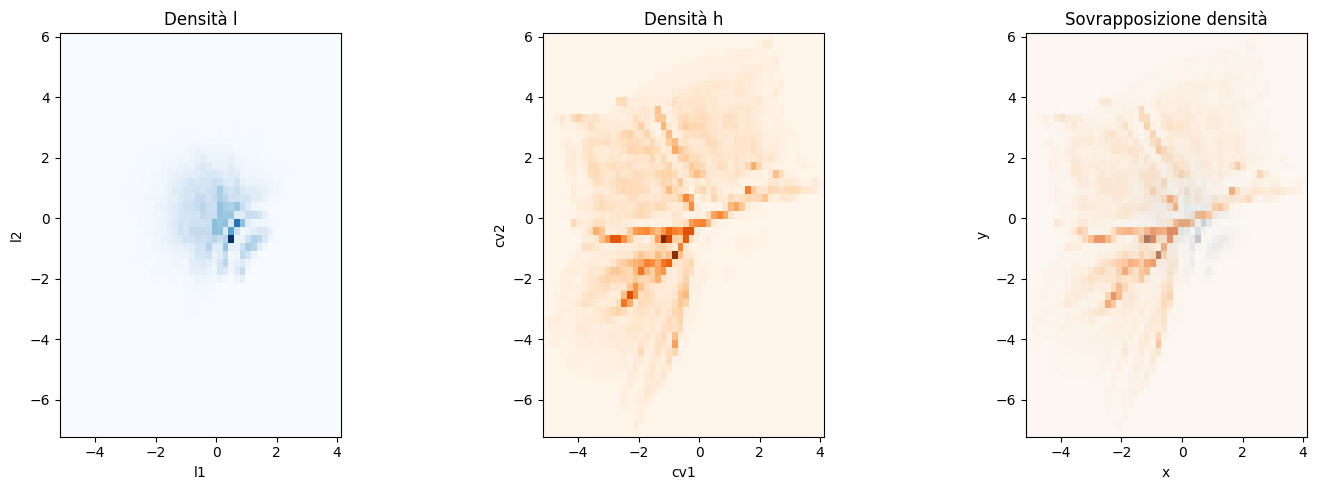

In [14]:
import matplotlib.pyplot as plt

# Limiti comuni per assi
xmin = min(l1.min(), cv1.min())
xmax = max(l1.max(), cv1.max())
ymin = min(l2.min(), cv2.min())
ymax = max(l2.max(), cv2.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Densità l ----
im1 = axes[0].hist2d(l1, l2, bins=50, range=[[xmin, xmax], [ymin, ymax]], cmap='Blues')
axes[0].set_title("Densità l")
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel("l1")
axes[0].set_ylabel("l2")

# ---- Densità h ----
im2 = axes[1].hist2d(cv1, cv2, bins=50, range=[[xmin, xmax], [ymin, ymax]], cmap='Oranges')
axes[1].set_title("Densità h")
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlabel("cv1")
axes[1].set_ylabel("cv2")

# ---- Sovrapposizione ----
# Creiamo due mappe 2D con gli stessi bin
H_l, xedges, yedges = np.histogram2d(l1, l2, bins=50, range=[[xmin, xmax], [ymin, ymax]])
H_h, _, _ = np.histogram2d(cv1, cv2, bins=[xedges, yedges])

# Plot sovrapposto con trasparenze
axes[2].imshow(H_l.T, origin='lower', extent=[xmin, xmax, ymin, ymax], cmap='Blues', alpha=0.6)
axes[2].imshow(H_h.T, origin='lower', extent=[xmin, xmax, ymin, ymax], cmap='Oranges', alpha=0.6)
axes[2].set_title("Sovrapposizione densità")
axes[2].set_aspect('equal', adjustable='box')
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.tight_layout()
plt.show()


# Properties
* Color the latent space above with the variables calculated in this section to explore the computed properties in the low dimentinal space

## RMSD & RG

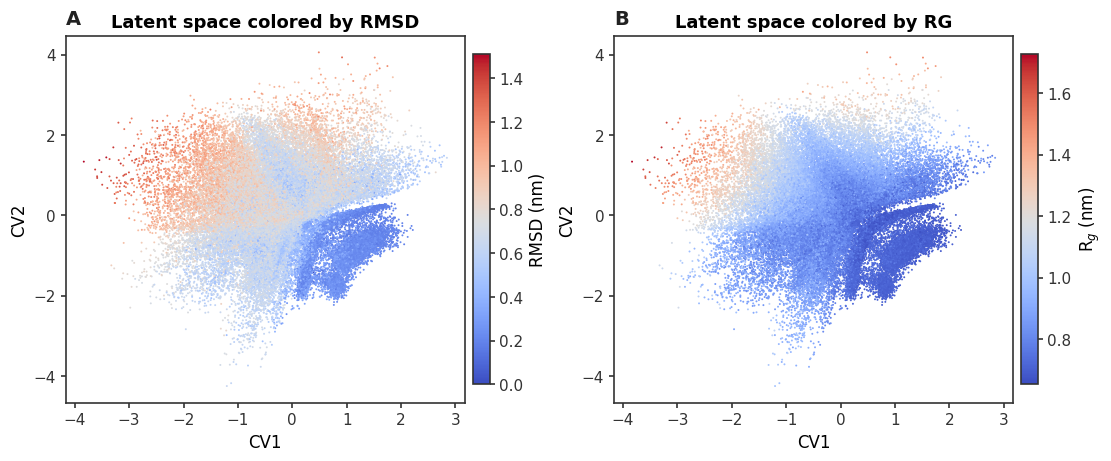

In [31]:
# === Latent space plots colored by RMSD and Rg (folded vs unfolded) ===
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------- INPUT ----------
# tr_full: md.Trajectory of your simulation
# conf: reference PDB file path
# lows: (n_frames, 2) array of latent space coordinates

# ---------- COMPUTE METRICS ----------
rg = md.compute_rg(tr_full)  # radius of gyration per frame
base = md.load(conf)
rmsd = md.rmsd(tr_full, base[0])  # RMSD vs native

# ---------- STYLE ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

def add_panel_label(ax, label, dx=0.0, dy=0.02):
    ax.text(0.0 + dx, 1.0 + dy, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, weight="bold", color="#222")

# ---------- COLOR MAP ----------
# coolwarm_r: blue = compact (folded), red = extended (unfolded)
cmap = plt.get_cmap("coolwarm")
norm_rmsd = mpl.colors.Normalize(vmin=np.min(rmsd), vmax=np.max(rmsd))
norm_rg = mpl.colors.Normalize(vmin=np.min(rg), vmax=np.max(rg))

# ---------- FIGURE ----------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

# (A) Latent space colored by RMSD
ax = axes[0]
sc1 = ax.scatter(lows[:, 0], lows[:, 1], c=rmsd, s=2, cmap=cmap, norm=norm_rmsd, rasterized=True, edgecolors='none')
ax.set_title("Latent space colored by RMSD", fontsize=13)
ax.set_xlabel("CV1"); ax.set_ylabel("CV2")
add_panel_label(ax, "A")
cbar1 = fig.colorbar(sc1, ax=ax, pad=0.02, shrink=0.9)
cbar1.set_label("RMSD (nm)", fontweight="medium")

# (B) Latent space colored by Rg
ax = axes[1]
sc2 = ax.scatter(lows[:, 0], lows[:, 1], c=rg, s=2, cmap=cmap, norm=norm_rg, rasterized=True, edgecolors='none')
ax.set_title("Latent space colored by RG", fontsize=13)
ax.set_xlabel("CV1"); ax.set_ylabel("CV2")
add_panel_label(ax, "B")
cbar2 = fig.colorbar(sc2, ax=ax, pad=0.02, shrink=0.9)
cbar2.set_label(r"R$_g$ (nm)", fontweight="medium")

# ---------- SAVE & SHOW ----------
plt.savefig("latent_RMSD_Rg_folded_unfolded.png", dpi=300, bbox_inches="tight")
plt.show()


## Torsions

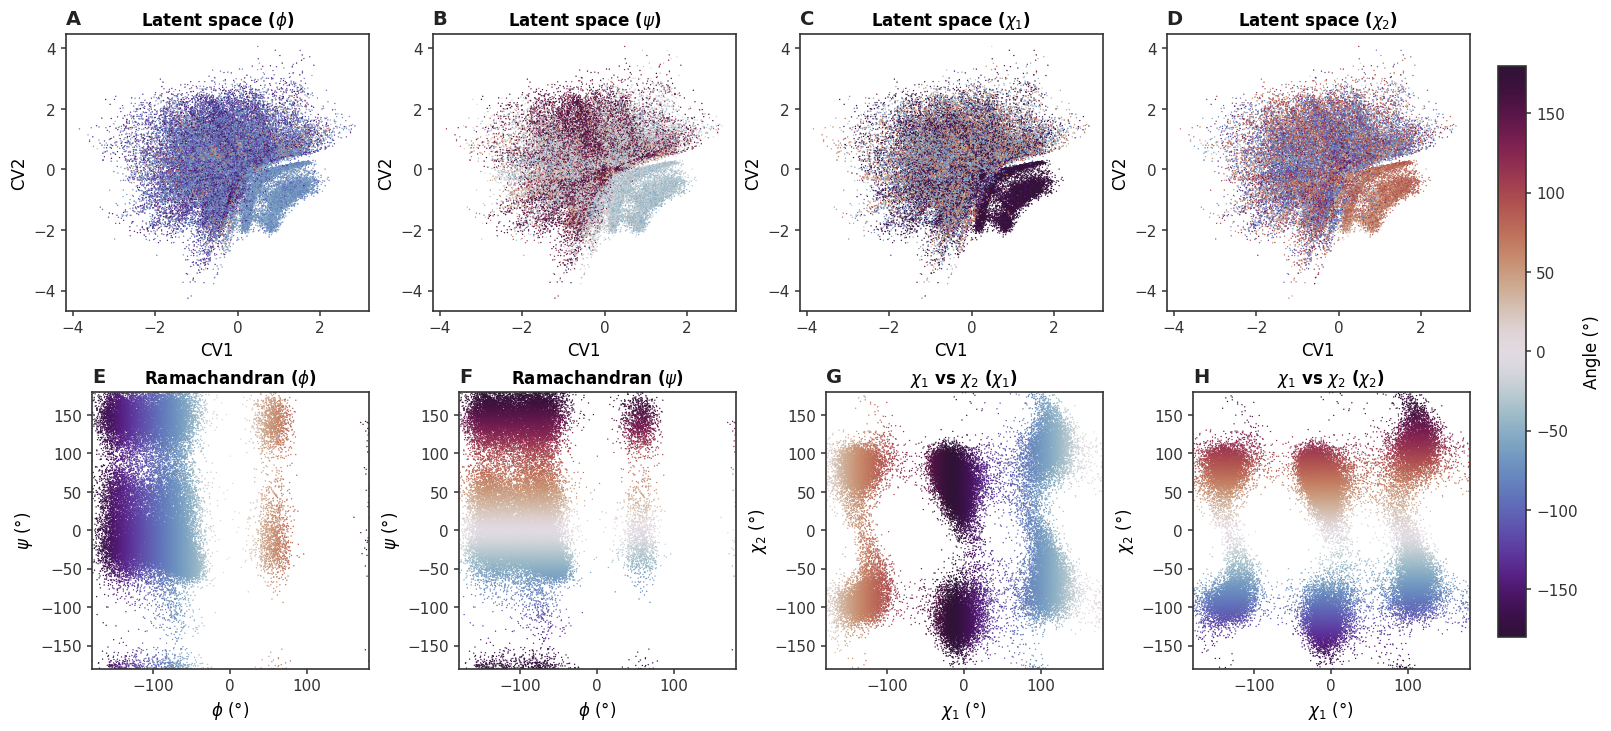

In [29]:
# === Torsion & CV plots (2×4 grid) with periodic tiling and χ1/χ2 recentring ===
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------- USER SETTINGS ----------
resid_pdb = 6   # residue number in the PDB
# 't' (trajectory) and 'proj' (n_frames×2 array of CVs) must already be loaded.

# ---------- STYLE ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

def add_panel_label(ax, label, dx=0.0, dy=0.02):
    ax.text(0.0 + dx, 1.0 + dy, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, weight="bold", color="#222")

# ---------- UTILS ----------
def wrap_deg(arr_rad):
    if arr_rad is None:
        return None
    deg = np.degrees(arr_rad)
    return ((deg + 180.0) % 360.0) - 180.0

def align_lengths(*arrays):
    n = min(a.shape[0] for a in arrays if a is not None)
    return tuple(a[:n] if a is not None else None for a in arrays)

def circular_mean_deg(arr_deg):
    """Circular mean in degrees (−180..180)."""
    r = np.radians(arr_deg)
    mu = np.degrees(np.arctan2(np.nanmean(np.sin(r)), np.nanmean(np.cos(r))))
    return mu

def recenter_deg(arr_deg, center=None):
    """Shift angles so that 'center' maps to 0°. Returns (shifted, center)."""
    if arr_deg is None:
        return None, 0.0
    if center is None:
        center = circular_mean_deg(arr_deg)
    shifted = ((arr_deg - center + 180.0) % 360.0) - 180.0
    return shifted, center

def tile_pair(a_deg, b_deg, c=None, thr=150.0):
    """
    Toroidal tiling for two angular variables in degrees.
    Duplicates points near ±180° by shifting ±360° so clusters remain continuous.
    If 'c' is provided, it's tiled with the same masks (used for color arrays).
    """
    segs_a = [a_deg]; segs_b = [b_deg]; segs_c = [c] if c is not None else None
    left   = a_deg < -thr; right = a_deg > thr
    bottom = b_deg < -thr; top   = b_deg > thr
    def _append(mask, da, db):
        if np.any(mask):
            segs_a.append(a_deg[mask] + da)
            segs_b.append(b_deg[mask] + db)
            if segs_c is not None: segs_c.append(c[mask])
    # edges
    _append(left, +360, 0); _append(right, -360, 0)
    _append(bottom, 0, +360); _append(top, 0, -360)
    # corners
    _append(left & bottom, +360, +360); _append(left & top, +360, -360)
    _append(right & bottom, -360, +360); _append(right & top, -360, -360)
    a_t = np.concatenate(segs_a); b_t = np.concatenate(segs_b)
    c_t = np.concatenate(segs_c) if segs_c is not None else None
    return a_t, b_t, c_t

# ---------- TORSIONS ----------
phi_idx, phi_all = md.compute_phi(t)
psi_idx, psi_all = md.compute_psi(t)
chi1_idx, chi1_all = md.compute_chi1(t)
chi2_idx, chi2_all = md.compute_chi2(t)
top = t.topology

# --- Select residue by PDB number ---
center_res = [r for r in top.residues if r.resSeq == resid_pdb][0]

def _pick_angle_for_res(idxs, vals, res):
    for i, q in enumerate(idxs):
        resids = [top.atom(a).residue.index for a in q]
        if res.index in resids:
            return vals[:, i]
    return None

phi = _pick_angle_for_res(phi_idx, phi_all, center_res)
psi = _pick_angle_for_res(psi_idx, psi_all, center_res)
chi1 = _pick_angle_for_res(chi1_idx, chi1_all, center_res)
chi2 = _pick_angle_for_res(chi2_idx, chi2_all, center_res)

# ---------- WRAP TO [−180, 180) ----------
phi_deg = wrap_deg(phi)
psi_deg = wrap_deg(psi)
chi1_deg = wrap_deg(chi1)
chi2_deg = wrap_deg(chi2)

# ---------- ALIGN LENGTHS WITH proj ----------
proj_a, phi_a, psi_a = align_lengths(proj, phi_deg, psi_deg)
if chi1_deg is not None and chi2_deg is not None:
    _, chi1_a, chi2_a = align_lengths(proj_a, chi1_deg, chi2_deg)
else:
    chi1_a = chi2_a = None

# ---------- RECENTER χ1/χ2 FOR χ-PANELS (coordinates only) ----------
if chi1_a is not None and chi2_a is not None:
    chi1_pos, chi1_ctr = recenter_deg(chi1_a)  # X coords for χ-panels
    chi2_pos, chi2_ctr = recenter_deg(chi2_a)  # Y coords for χ-panels
    chi2_pos += 50.0 
else:
    chi1_pos = chi2_pos = None

# ---------- TILING ----------
# φ/ψ (use absolute angles)
phi_t_phiC, psi_t_phiC, col_phi = tile_pair(phi_a, psi_a, c=phi_a)
phi_t_psiC, psi_t_psiC, col_psi = tile_pair(phi_a, psi_a, c=psi_a)

# χ1/χ2 (use recentered positions for continuity; colors remain absolute)
if chi1_pos is not None and chi2_pos is not None:
    chi1_t_c1, chi2_t_c1, col_c1 = tile_pair(chi1_pos, chi2_pos, c=chi1_a)  # colored by χ1 (absolute)
    chi1_t_c2, chi2_t_c2, col_c2 = tile_pair(chi1_pos, chi2_pos, c=chi2_a)  # colored by χ2 (absolute)
else:
    chi1_t_c1 = chi2_t_c1 = col_c1 = None
    chi1_t_c2 = chi2_t_c2 = col_c2 = None

# ---------- COLORMAP ----------
vmin, vmax = -180, 180
cmap = "twilight_shifted"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ---------- FIGURE 2×4 ----------
fig, axes = plt.subplots(2, 4, figsize=(16, 7.2), constrained_layout=True)

# === ROW 1: CV plots ===
axes[0, 0].scatter(proj_a[:, 0], proj_a[:, 1], c=phi_a, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[0, 0].set_title(r"Latent space ($\phi$)")
axes[0, 0].set_xlabel("CV1"); axes[0, 0].set_ylabel("CV2")
add_panel_label(axes[0, 0], "A")

axes[0, 1].scatter(proj_a[:, 0], proj_a[:, 1], c=psi_a, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[0, 1].set_title(r"Latent space ($\psi$)")
axes[0, 1].set_xlabel("CV1"); axes[0, 1].set_ylabel("CV2")
add_panel_label(axes[0, 1], "B")

if chi1_a is not None:
    axes[0, 2].scatter(proj_a[:, 0], proj_a[:, 1], c=chi1_a, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[0, 2].set_title(r"Latent space ($\chi_1$)")
axes[0, 2].set_xlabel("CV1"); axes[0, 2].set_ylabel("CV2")
add_panel_label(axes[0, 2], "C")

if chi2_a is not None:
    axes[0, 3].scatter(proj_a[:, 0], proj_a[:, 1], c=chi2_a, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[0, 3].set_title(r"Latent space ($\chi_2$)")
axes[0, 3].set_xlabel("CV1"); axes[0, 3].set_ylabel("CV2")
add_panel_label(axes[0, 3], "D")

# === ROW 2: Ramachandran + χ plots ===
axes[1, 0].scatter(phi_t_phiC, psi_t_phiC, c=col_phi, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[1, 0].set_title(r"Ramachandran ($\phi$)")
axes[1, 0].set_xlabel(r"$\phi$ (°)"); axes[1, 0].set_ylabel(r"$\psi$ (°)")
axes[1, 0].set_xlim(vmin, vmax); axes[1, 0].set_ylim(vmin, vmax)
axes[1, 0].set_aspect("equal")
add_panel_label(axes[1, 0], "E")

axes[1, 1].scatter(phi_t_psiC, psi_t_psiC, c=col_psi, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[1, 1].set_title(r"Ramachandran ($\psi$)")
axes[1, 1].set_xlabel(r"$\phi$ (°)"); axes[1, 1].set_ylabel(r"$\psi$ (°)")
axes[1, 1].set_xlim(vmin, vmax); axes[1, 1].set_ylim(vmin, vmax)
axes[1, 1].set_aspect("equal")
add_panel_label(axes[1, 1], "F")

if chi1_t_c1 is not None:
    axes[1, 2].scatter(chi1_t_c1, chi2_t_c1, c=col_c1, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[1, 2].set_title(r"$\chi_1$ vs $\chi_2$ ($\chi_1$)")
axes[1, 2].set_xlabel(r"$\chi_1$ (°)"); axes[1, 2].set_ylabel(r"$\chi_2$ (°)")
axes[1, 2].set_xlim(vmin, vmax); axes[1, 2].set_ylim(vmin, vmax)
axes[1, 2].set_aspect("equal")
add_panel_label(axes[1, 2], "G")

if chi1_t_c2 is not None:
    axes[1, 3].scatter(chi1_t_c2, chi2_t_c2, c=col_c2, s=1, cmap=cmap, norm=norm, rasterized=True, edgecolors='none')
axes[1, 3].set_title(r"$\chi_1$ vs $\chi_2$ ($\chi_2$)")
axes[1, 3].set_xlabel(r"$\chi_1$ (°)"); axes[1, 3].set_ylabel(r"$\chi_2$ (°)")
axes[1, 3].set_xlim(vmin, vmax); axes[1, 3].set_ylim(vmin, vmax)
axes[1, 3].set_aspect("equal")
add_panel_label(axes[1, 3], "H")

# === COLORBAR (condivisa, scala assoluta −180..180) ===
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("Angle (°)")

# === SAVE & SHOW ===
plt.savefig("Fig7_torsions_latent_2x4_res6_recentered_chi.png", dpi=300, bbox_inches="tight")
plt.show()


## Native contacts

## Alpha elics
* **Traj** must be the tranining .xtc and .pdb

Average α-helix content: 0.160


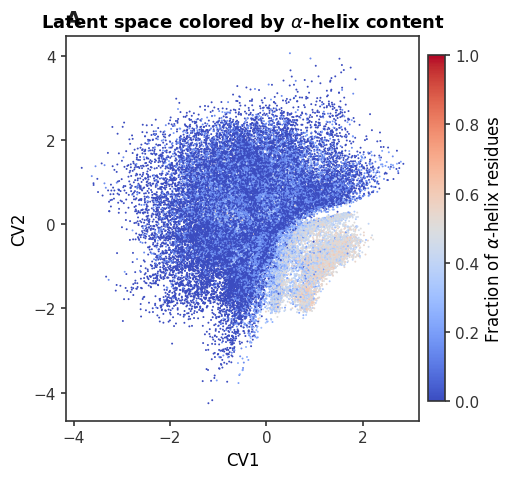

In [33]:
# === DSSP-based α-helix content plotted in latent space ===
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------- INPUT ----------
# tr_full: md.Trajectory
# lows: (n_frames, 2) array of latent-space coordinates

# ---------- COMPUTE DSSP ----------
dssp = md.compute_dssp(tr_full, simplified=True)  # secondary structure per residue
alpha_content_per_frame = np.mean(dssp == 'H', axis=1)  # fraction of α-helix residues per frame
average_alpha_helix_content = np.mean(alpha_content_per_frame)

print(f"Average α-helix content: {average_alpha_helix_content:.3f}")

# ---------- STYLE ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

def add_panel_label(ax, label, dx=0.0, dy=0.02):
    ax.text(0.0 + dx, 1.0 + dy, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, weight="bold", color="#222")

# ---------- COLOR MAP ----------
# from blue (no helix) to red (fully helical)
cmap = plt.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

# ---------- PLOT ----------
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(lows[:, 0], lows[:, 1], c=alpha_content_per_frame,
                cmap=cmap, norm=norm, s=2, rasterized=True, edgecolors='none')

ax.set_xlabel("CV1")
ax.set_ylabel("CV2")
ax.set_title(r"Latent space colored by $\alpha$-helix content", fontsize=13)
add_panel_label(ax, "A")

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label(r"Fraction of $\alpha$-helix residues", fontweight="medium")

# ---------- SAVE & SHOW ----------
plt.savefig("latent_alpha_content.png", dpi=300, bbox_inches="tight")
plt.show()


## Angles

In [ ]:
atom_indices = tr_full.topology.select("resid 2 and name N")[0], \
               tr_full.topology.select("resid 12 and name C")[0], \
               tr_full.topology.select("resid 19 and name O")[0]

# Radiants
angles = md.compute_angles(tr_full, [atom_indices])  

# Degree
angles_deg = np.rad2deg(angles[:, 0])
plt.scatter(lows[:, 0], lows[:, 1], c=angles_deg, cmap="rainbow", s=1)

## Plane
* **x**: same as above.
* **y**:  same as above

In [ ]:
atom1 = tr_full.topology.select("resid 2 and name N")[0]
atom2 = tr_full.topology.select("resid 8 and name C")[0]
atom3 = tr_full.topology.select("resid 13 and name C")[0]
atom4 = tr_full.topology.select("resid 19 and name O")[0]

# Radiants
dihedrals = md.compute_dihedrals(tr_full, [[atom1, atom2, atom3, atom4]])
# Degree
dihedrals_deg = np.rad2deg(dihedrals[:, 0])  
plt.scatter(lows[:, 0], lows[:, 1], c=dihedrals_deg, cmap="rainbow", s=1)

In [ ]:
## Save all pictures

In [ ]:
os.makedirs("0x.picture", exist_ok=True)

for file in glob.glob("*.png"):
        shutil.move(file, os.path.join("../Pictures", file))